In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import random

from ISLP import load_data
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, cut_tree
from ISLP.cluster import compute_linkage

seed = 1672

In [2]:
Boston = load_data('Boston')
Boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


## Initial Data Exploration

In [3]:
Boston.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
lstat      float64
medv       float64
dtype: object

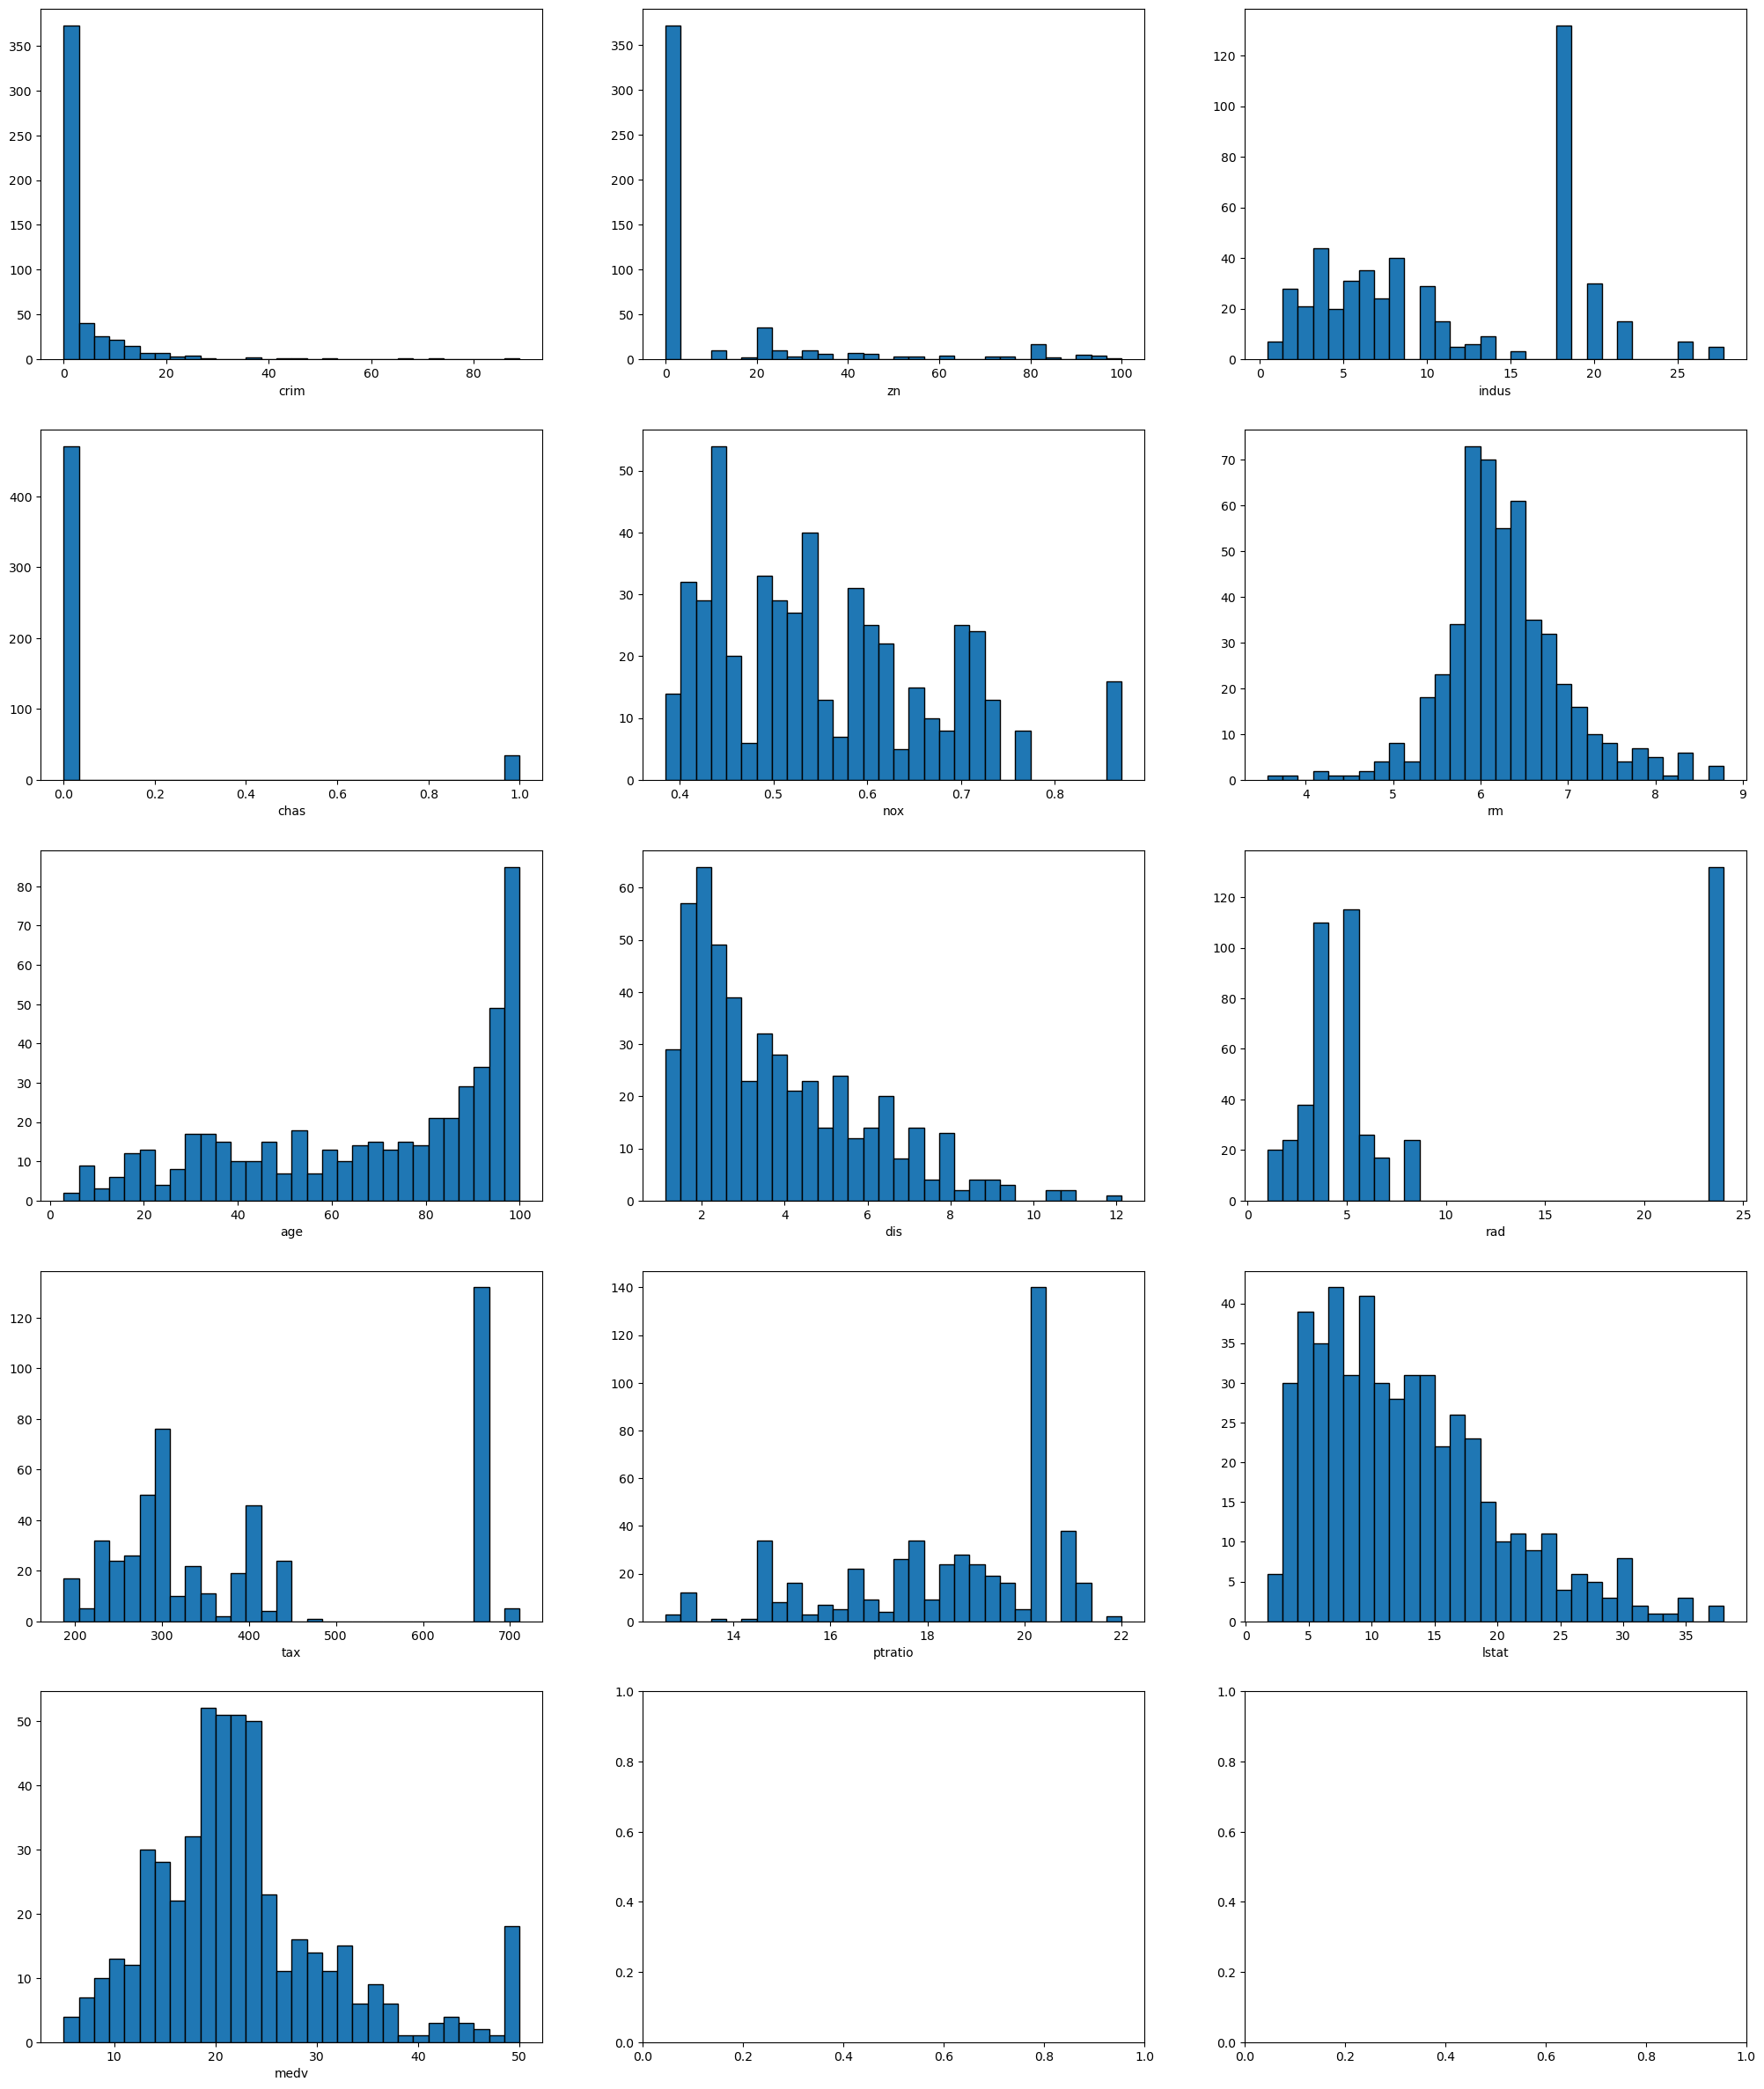

In [4]:
# Initialize the plots before drawing them
nrows = 5
ncols = 3
figsize = (5*nrows, 10*ncols)

fig, axes = subplots(nrows=nrows,
                     ncols=ncols,
                     figsize=figsize)

# Assign a grid location to each index
def range_to_grid(i, nrows, ncols):
    x=[]
    y=[]
    for n in range(nrows*ncols):
        x.append(n // ncols)
        y.append(n % ncols)
        # print(n,x[n],y[n]) # for testing this function
    return x[i],y[i]

# Plot the variables as paired boxplots
for j, col in enumerate(Boston.columns):
    r, c = range_to_grid(j, nrows, ncols)
    ax = axes[r, c]

    ax.hist(Boston[col], bins=30, edgecolor='black')

    ax.set_xlabel(col)

In [ ]:
Boston.corr()

## Standardization

In [ ]:
scaler = StandardScaler().set_output(transform="pandas")
Boston_std = scaler.fit_transform(Boston)
pd.DataFrame(Boston_std)

## PCA

### First we'll conduct PCA on only three of the columns.

In [ ]:
subset1 = Boston_std[['age', 'nox', 'ptratio']]

### Notice that `age` and `nox` are highly correlated, but `ptratio` is as not strongly correlated with either of them.

In [ ]:
pd.DataFrame(subset1.corr())

### Fit the principal components.

In [ ]:
PCA_subset = PCA()
PCA_subset.fit(subset1)

### When we print the components by each variable, we can see that the first (0th) component is influenced by `age` and `nox` while the second (1st) component is mostly influenced by `ptratio`. 

This is consistent with the correlations that we calculated earlier.

In [ ]:
components_subset = pd.DataFrame(PCA_subset.components_, columns=subset1.columns.to_list())
components_subset

### What percent of variance is explained by each component?

In [ ]:
PCA_subset.explained_variance_ratio_

### Next we'll tranform the original data to the principal components and graph the records along first two components.

In [ ]:
PCA_subset_scores = PCA_subset.transform(subset1)

In [ ]:
i, j = 0, 1 # which components
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(PCA_subset_scores[:,0], PCA_subset_scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(PCA_subset.components_.shape[1]):
    ax.arrow(0, 0, PCA_subset.components_[i,k], PCA_subset.components_[j,k])
    ax.text(PCA_subset.components_[i,k],
            PCA_subset.components_[j,k],
            subset1.columns[k])

### Now conduct principal components analysis on the entire standardized Boston dataset.

In [ ]:
PCA_Boston = #fillin

### Calculate the components and include the column names

In [ ]:
components_Boston = #fillin

### Based on these components, determine which variable has the _most_ influence on the first principal component, and which variable has the _least_ influence on the first principal component. 

Note that the first principal component will appear as component 0

In [ ]:
#fillin 
var_most_influencing_1st_pc = 'type the variable name in these quotes'
var_least_influencing_1st_pc = 'type the variable name in these quotes'

## K-means Clustering

### First we'll conduct k-means clustering using only two variables, so that we can graph the results in 2 dimensions.

In [ ]:
# create the dataset
subset2 = Boston_std[['rm', 'indus']]

In [ ]:
# build the clusters
kmeans1 = KMeans(n_clusters=3,
                random_state=seed,
                n_init=1).fit(subset2)

In [ ]:
# record the cluster assignments
cluster_km1 = pd.DataFrame(kmeans1.labels_)
cluster_km1

In [ ]:
# plot the clusters
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(subset2['rm'], subset2['indus'], c=cluster_km1)
ax.set_title("K-Means Clustering Results with K=3")
ax.set_xlabel('rm')
ax.set_ylabel('indus');

### Let's try this again, but choosing the optimal cluster assignments across 1000 iterations.

In [ ]:
kmeans2 = KMeans(n_clusters=3,
                random_state=seed,
                n_init=1000).fit(subset2)

cluster_km2 = pd.DataFrame(kmeans2.labels_)

fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(subset2['rm'], subset2['indus'], c=cluster_km2)
ax.set_title("K-Means Clustering Results with K=3")
ax.set_xlabel('rm')
ax.set_ylabel('indus');

### Now let's try 4 clusters instead of 3

In [ ]:
kmeans3 = KMeans(n_clusters=4,
                random_state=seed,
                n_init=1000).fit(subset2)

cluster_km3 = pd.DataFrame(kmeans3.labels_)

fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.scatter(subset2['rm'], subset2['indus'], c=cluster_km3)
ax.set_title("K-Means Clustering Results with K=4")
ax.set_xlabel('rm')
ax.set_ylabel('indus');

### In the picture displaying 4 clusters (above), there are several points that are classified into one cluster but seem much closer to the centroid of another cluster. Why is that?

#fillin Type your answer here.

### Now run a K-means analysis on the entire standardized Boston dataset (with all variables included). Use 5 clusters, 1000 iterations, and the same seed as prior K-means models.

### Store the model as "kmeans_all" and the cluster assignments as "cluster_km_all"

In [ ]:
kmeans_all = #fillin

cluster_km_all = #fillin

### What variable in the Boston dataset is most correlated with the cluster assignments of "kmeans_all"? 

In [ ]:
# coding work can go here


In [ ]:
# provide answer here, with variable name inside the quotes
var_most_correlated_w_kmeans = 'type the variable name here'

## Hierarchical Clustering

### To better visualize this, let's do a first example on subset of _rows_ of the Boston data. 

In [ ]:
# Create a random sample by randomly choosing row indices
random.seed(seed)
index = random.sample(range(Boston_std.shape[0]), 12)

subset3 = Boston_std.iloc[index]
subset3

### We'll use complete linkage for the clustering

In [ ]:
HClust1 = AgglomerativeClustering
hc_comp = HClust1(distance_threshold=0,
                  n_clusters=None,
                  linkage='complete')
hc_comp.fit(subset3)

### We can create a dendrogram, too.

In [ ]:
linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=subset3.index,
           color_threshold=-np.inf,
           above_threshold_color='black')
ax.set_ylabel('dissimilarity');

### We can even add color to the dendrogram to distinguish between colors.

Note that we specify a dissimilarity threshold (based on the linkage choice) in this function, rather than a number of clusters.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=subset3.index,
           color_threshold=6, 
           above_threshold_color='black')
ax.set_ylabel('dissimilarity');

### We can also store the cluster assignments.

In [ ]:
cluster_h1 = cut_tree(linkage_comp, n_clusters=2)
cluster_h1

### Without changing the underlying model, we can create 3 (or more) clusters instead of 2.

In [ ]:
cluster_h2 = cut_tree(linkage_comp, n_clusters=3)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dendrogram(linkage_comp,
           ax=ax,
           leaf_rotation=90,
           labels=subset3.index,
           color_threshold=4.75, 
           above_threshold_color='black')
ax.set_ylabel('dissimilarity');

### Let's try doing hierarchical clustering with _average_ linkage.

In [ ]:
hc_avg = HClust1(distance_threshold=0,
                  n_clusters=None,
                  linkage='average')
hc_avg.fit(subset3)

linkage_avg = compute_linkage(hc_avg)
cluster_h3 = cut_tree(linkage_avg, n_clusters=3)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dendrogram(linkage_avg,
           ax=ax,
           leaf_rotation=90,
           labels=subset3.index,
           color_threshold=4.45, 
           above_threshold_color='black')
ax.set_ylabel('dissimilarity');

### Now run hierarchical clustering with complete linkage on the entire standardized Boston dataset (with all records included). 

### Use 5 clusters and store the cluster assignments as "cluster_h_all"

In [ ]:
hc_all = #fillin

cluster_h_all = #fillin


### Using the cluster assignments in `cluster_h_all`, how many records of the Boston data are in the largest cluster? How about the smallest cluster? 

In [ ]:
# coding work can go here


In [ ]:
# provide answers here. Do not enter these numbers as strings (i.e., not in quotes)
records_in_largest_cluster = #type number here
records_in_smallest_cluster = #type number here

### Why did we complete the analysis in this notebook without creating train and test sets?

Type your answer here.